# Unitary Dataset Exploration

This notebook inspects a saved unitary-compilation dataset end to end.

It focuses on:
- circuit structure: circuit lengths, active qubits, gate usage
- prompt structure: exact prompt counts, prompt sizes, gate presence in prompts
- unitary structure: sampled traces, diagonal energy, distances, eigenphases, and a 2D embedding

The heavy unitary diagnostics are computed on a configurable sample so the notebook remains usable on large saved datasets.

In [1]:
import os
import sys
from pathlib import Path

from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from notebooks.unitary_dataset_exploration_helper import (
    DEFAULT_TRAINING_CFG,
    analyze_unitary_dataset,
    default_dataset_path,
    maybe_dataframe,
    plot_circuit_distributions,
    plot_prompt_distributions,
    plot_unitary_geometry,
    plot_unitary_metric_distributions,
)


In [2]:
DATASET_PATH = Path(default_dataset_path())
DEVICE = "cpu"
MAKE_CONTIGUOUS = False
MAX_UNITARY_SAMPLES = 2048
MAX_EIGEN_UNITARIES = 512
PAIRWISE_PAIRS = 4096
SEED = 0

print("TRAINING_CFG =", DEFAULT_TRAINING_CFG)
print("DATASET_PATH =", DATASET_PATH)
print("DEVICE =", DEVICE)
print("MAKE_CONTIGUOUS =", MAKE_CONTIGUOUS)
print("MAX_UNITARY_SAMPLES =", MAX_UNITARY_SAMPLES)
print("MAX_EIGEN_UNITARIES =", MAX_EIGEN_UNITARIES)
print("PAIRWISE_PAIRS =", PAIRWISE_PAIRS)


TRAINING_CFG = /workspace/qcircuit-generation/conf/training/paper_unitary.yaml
DATASET_PATH = /workspace/qcircuit-generation/datasets/paper_qiskit/unitary_3q_dataset
DEVICE = cpu
MAKE_CONTIGUOUS = False
MAX_UNITARY_SAMPLES = 2048
MAX_EIGEN_UNITARIES = 512
PAIRWISE_PAIRS = 4096


In [5]:
analysis = analyze_unitary_dataset(
    DATASET_PATH,
    device=DEVICE,
    make_contiguous=MAKE_CONTIGUOUS,
    max_unitary_samples=MAX_UNITARY_SAMPLES,
    max_eigen_unitaries=MAX_EIGEN_UNITARIES,
    pairwise_pairs=PAIRWISE_PAIRS,
    seed=SEED,
)

display(maybe_dataframe(analysis["overview"]))


[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/paper_qiskit/unitary_3q_dataset/dataset/ds_x.safetensors` onto device: cpu.
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/paper_qiskit/unitary_3q_dataset/dataset/ds_y.safetensors` onto device: cpu.
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/paper_qiskit/unitary_3q_dataset/dataset/ds_U.safetensors` onto device: cpu.
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/paper_qiskit/unitary_3q_dataset/dataset/ds_z.safetensors` onto device: cpu.
[INFO]: Instantiated config_dataset from given config on cpu.


,dataset_dir,config_target,num_samples,x_shape,u_shape,num_qubits_config,min_gates_config,max_gates_config,pad_constant,gate_pool,...,invalid_prompt_count,circuit_length_min,circuit_length_median,circuit_length_mean,circuit_length_max,active_qubits_min,active_qubits_median,active_qubits_mean,active_qubits_max,sampled_unitaries_for_metrics
0,/workspace/qcircuit-generation/datasets/paper_...,my_genQC.dataset.circuits_dataset.MixedCircuit...,657780,"(657780, 3, 12)","(657780, 2, 8, 8)",3,2,12,7,"[h, cx, z, x, ccx, swap]",...,0,1.0,7.0,7.492607,12.0,1.0,3.0,2.977879,3.0,2048


In [6]:
print("Circuit length distribution")
display(maybe_dataframe(analysis["length_rows"]))

print("Active-qubit distribution")
display(maybe_dataframe(analysis["active_qubit_rows"]))

print("Top prompts")
display(maybe_dataframe(analysis["prompt_rows"][:20]))

print("Prompt-size summary")
display(maybe_dataframe(analysis["prompt_size_rows"]))

print("Prompt gate presence")
display(maybe_dataframe(analysis["prompt_gate_rows"]))

print("Circuit gate frequencies")
display(maybe_dataframe(analysis["gate_frequency_rows"]))

print("Sampled unitary metric summary")
display(maybe_dataframe(analysis["unitary_sample"]["metric_summary"]))

print("Sampled unitary metrics grouped by prompt size")
display(maybe_dataframe(analysis["unitary_sample"]["by_prompt_size_rows"]))


Circuit length distribution


,circuit_length,count
0,1,21
1,2,372
2,3,6515
3,4,51355
4,5,89926
5,6,100922
6,7,95220
7,8,93536
8,9,74900
9,10,71721


Active-qubit distribution


,active_qubits,count
0,1,189
1,2,14173
2,3,643418


Top prompts


...

,token,gate,count,fraction
0,1,h,688909,0.139781
1,2,cx,933935,0.189497
2,3,z,689191,0.139838
3,4,x,688104,0.139618
4,5,ccx,1026290,0.208236
5,6,swap,902058,0.183029


Sampled unitary metric summary


,sampled_unitaries,unitary_dim,trace_abs_norm_min,trace_abs_norm_median,trace_abs_norm_mean,trace_abs_norm_max,diag_energy_frac_min,diag_energy_frac_median,diag_energy_frac_mean,diag_energy_frac_max,hs_identity_distance_min,hs_identity_distance_median,hs_identity_distance_mean,hs_identity_distance_max,unitarity_error_min,unitarity_error_median,unitarity_error_mean,unitarity_error_max
0,2048,8,0.0,0.125,0.125985,1.0,0.0,0.125,0.195888,1.0,0.0,0.935414,0.929222,1.0,0.0,0.0,0.000202,0.000604


Sampled unitary metrics grouped by prompt size


,prompt_size,count,mean_length,mean_trace_abs_norm,mean_diag_energy_frac,mean_hs_identity_distance
0,2,324,7.524691,0.180598,0.298026,0.894103
1,3,402,7.427861,0.138491,0.207818,0.919830
2,4,427,7.416862,0.114161,0.172850,0.937958
3,5,454,7.599119,0.108725,0.169589,0.939915
4,6,441,7.512472,0.103677,0.159351,0.944119


(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'Top 15 Prompts'}, xlabel='Samples', ylabel='Prompt'>, <Axes: title={'center': 'Gate Presence in Prompts'}, xlabel='Gate', ylabel='Fraction of samples'>,
        <Axes: title={'center': 'Mean Circuit Length by Prompt Size'}, xlabel='Allowed gates in prompt', ylabel='Mean circuit length'>], dtype=object))

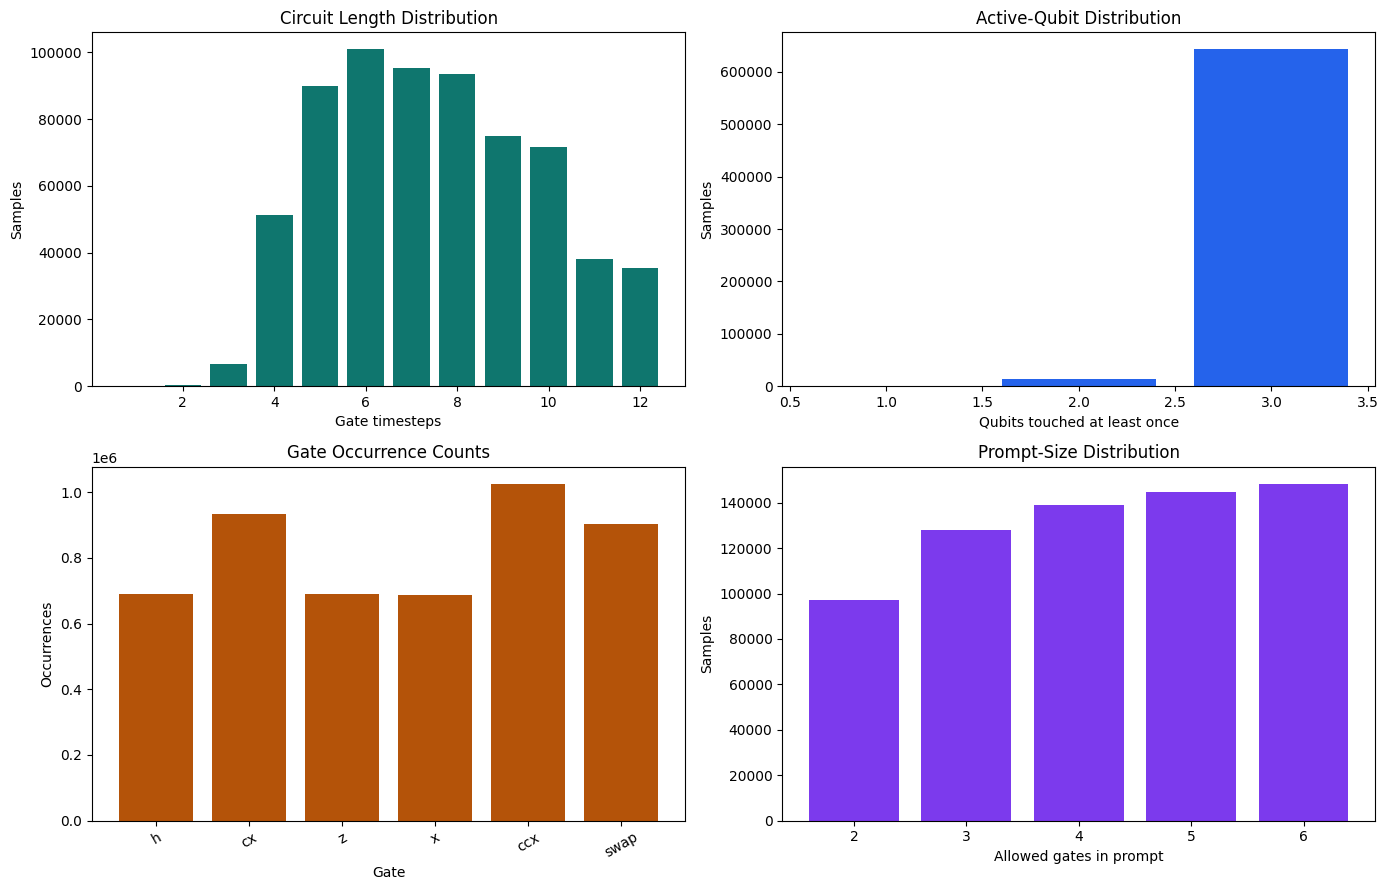

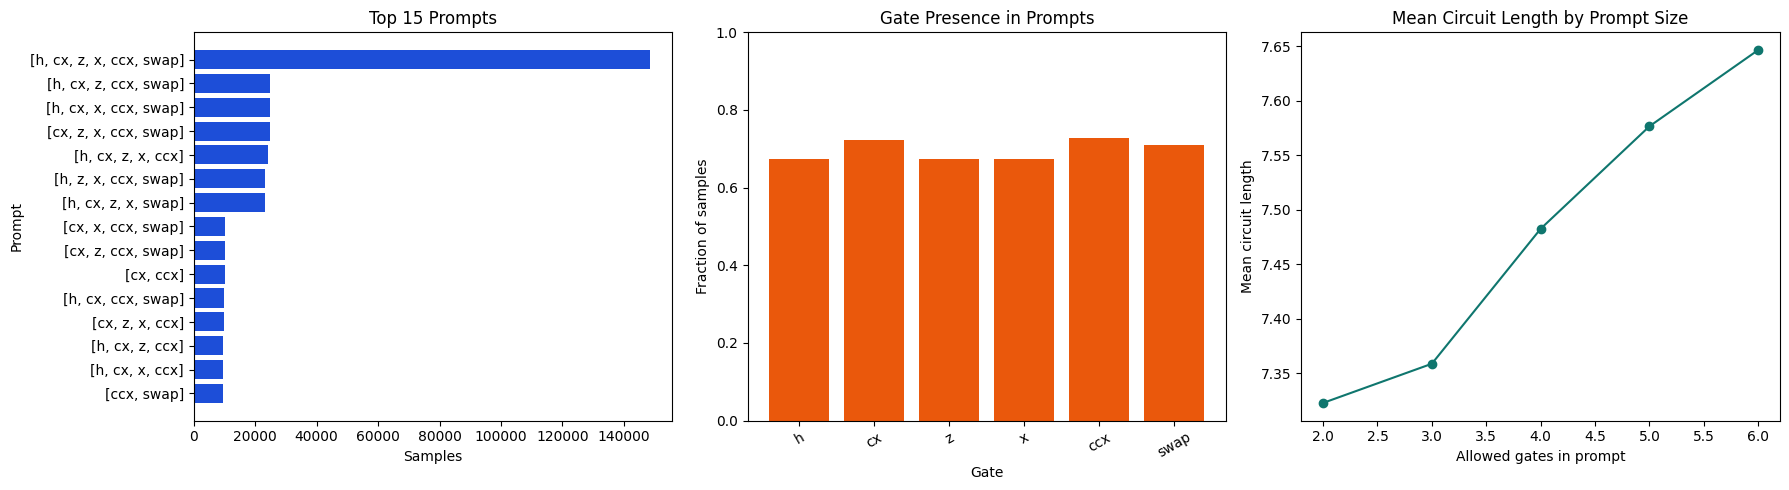

In [7]:
plot_circuit_distributions(analysis)
plot_prompt_distributions(analysis, top_k=15)


(<Figure size 1800x500 with 4 Axes>,
 array([<Axes: title={'center': 'Eigenphase Distribution'}, xlabel='Phase [rad]', ylabel='Eigenvalues'>,
        <Axes: title={'center': 'Pairwise Unitary Distances'}, xlabel='Phase-invariant Hilbert-Schmidt distance', ylabel='Random sample pairs'>,
        <Axes: title={'center': 'PCA of Flattened Unitaries'}, xlabel='PC 1', ylabel='PC 2'>], dtype=object))

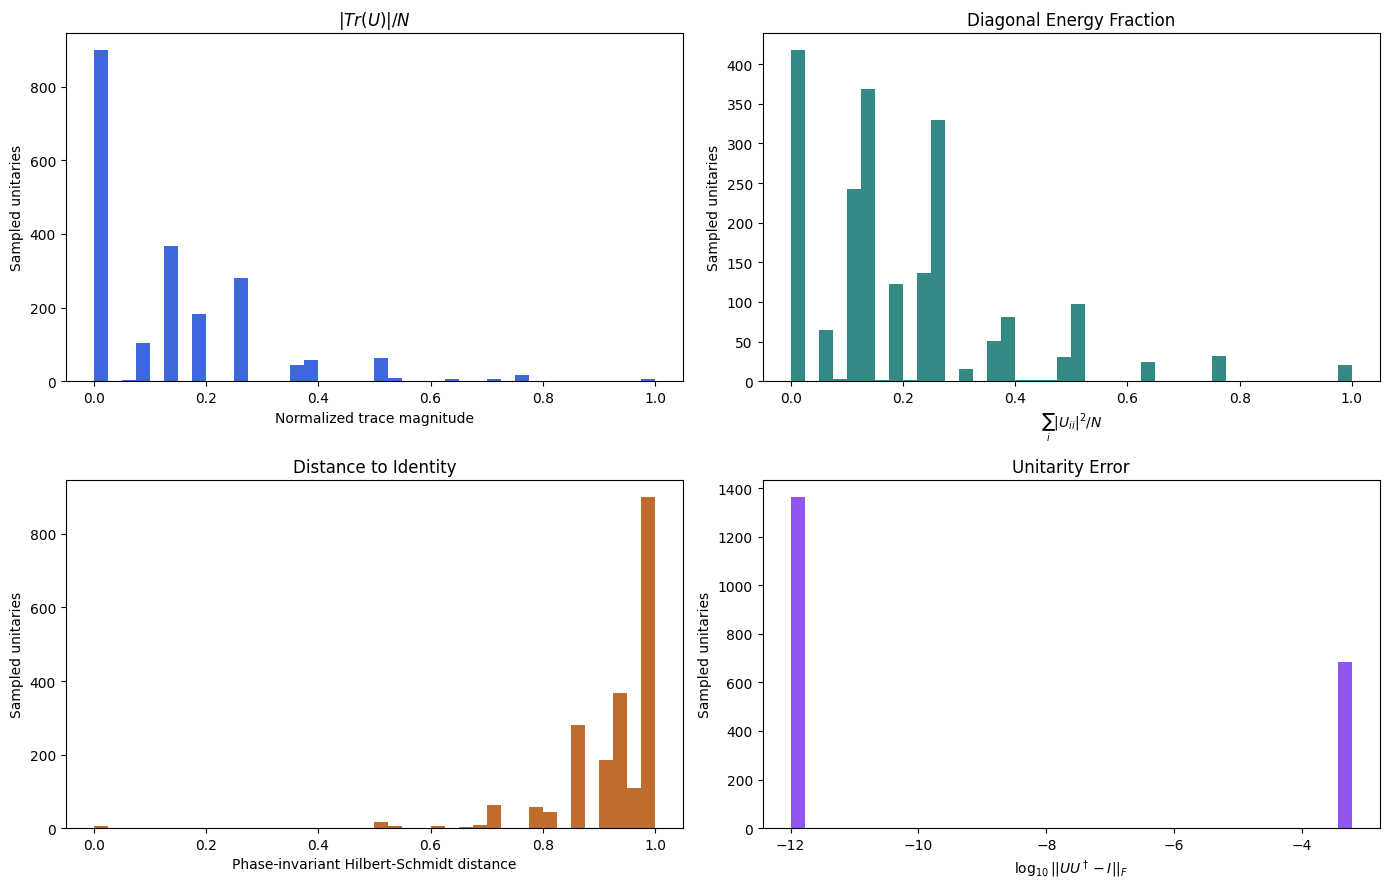

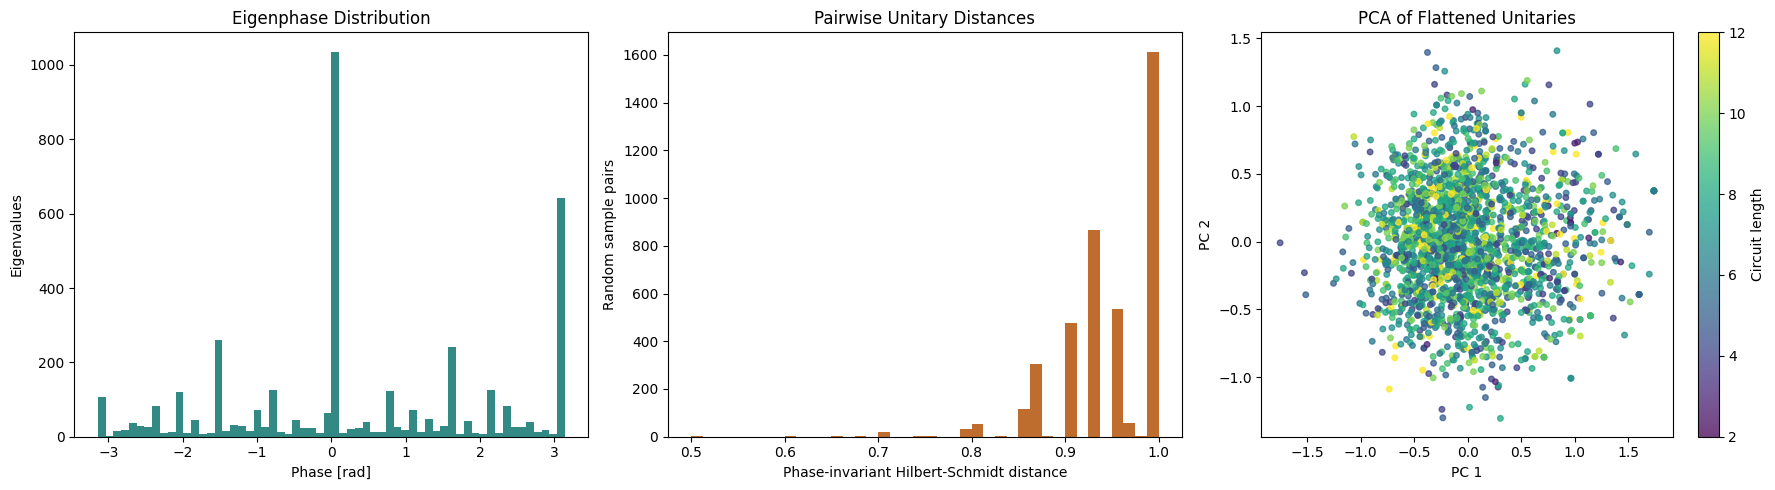

In [8]:
plot_unitary_metric_distributions(analysis)
plot_unitary_geometry(analysis)
